# Case Study: Moosic

## Import libraries and files

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
sheet_id = "14OFjSGgL5Vgni6ig09cqQ80v26HwI1H4sASnyE3AMh8"
sheet_name = "383826049"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}"
raw_df = pd.read_csv(url)

In [ ]:
raw_df = raw_df.drop(columns=raw_df.columns[0])
raw_df["index"] = raw_df["name"] + " - " + raw_df["artist"]
raw_df = raw_df.set_index("index")

In [ ]:
features_df = raw_df.drop(columns=["name", "artist", "key", "loudness", "mode", "speechiness", "liveness", "type", "duration_ms", "time_signature", "id", "html"]).copy()

In [ ]:
features_df.sample(5)

,danceability,energy,acousticness,instrumentalness,valence,tempo
index,,,,,,
Vagabund - Bausa,0.894,0.557,0.224000,0.000587,0.6510,102.940
Ceased By Failure - Rottrevore,0.281,0.938,0.000023,0.926000,0.2990,107.998
Nature Boy - Jan Johansson,0.438,0.182,0.983000,0.841000,0.0639,65.535
Il barbiere di Siviglia: Overture (Sinfonia) - Gioachino Rossini,0.348,0.303,0.961000,0.869000,0.3410,93.016
Mad Love - Sean Paul,0.793,0.824,0.006000,0.000003,0.6110,98.019


## 1. Min-Max-Scaling

In [ ]:
minmax_scaler = MinMaxScaler()
minmax_df = minmax_scaler.fit_transform(features_df)

In [ ]:
minmax_df.sample(5)

,danceability,energy,acousticness,instrumentalness,valence,tempo
index,,,,,,
Abigor - Cryptopsy,0.239917,0.961,0.000264,0.943147,0.163452,0.477462
War In Paradise - Studio - Vital Remains,0.228542,0.969,0.000038,0.577665,0.351269,0.730903
Dominion - Rotten Sound,0.288521,0.991,0.000002,0.003117,0.282234,0.666718
Ahora Dice - Chris Jedi,0.728025,0.690,0.250000,0.000000,0.408122,0.673139
Me pones en Tencion - Zion & Lennox,0.908997,0.807,0.027811,0.000001,0.895431,0.439189


### 1.1. Estimate the number of clusters (k)

#### 1.1.1. Inertia and the elbow method

In [ ]:
max_clusters = 12
within_cluster_sse = []
for k in range(1, max_clusters + 1):
  model = KMeans(n_clusters=k, random_state=42)
  model.fit(minmax_df)
  within_cluster_sse.append(model.inertia_)

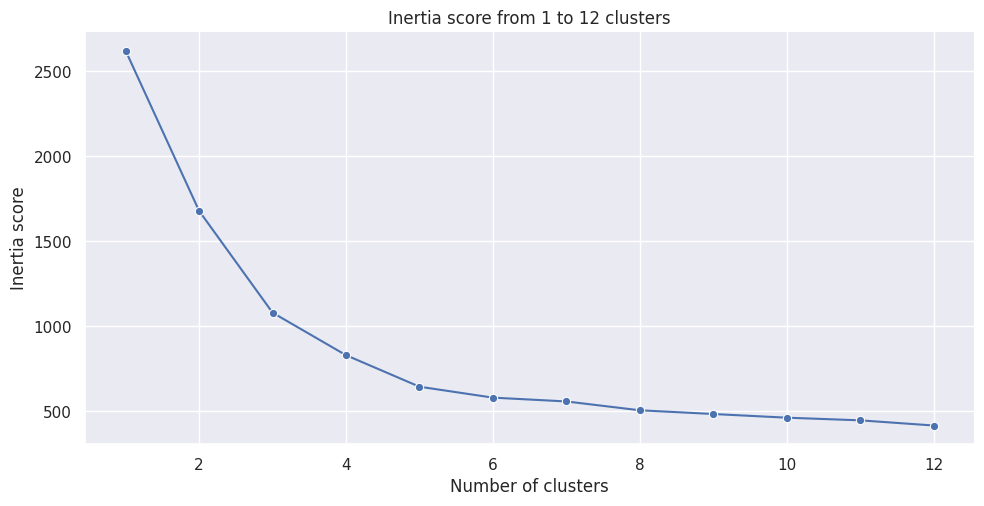

In [ ]:
sns.relplot(
  x=range(1, max_clusters + 1),
  y=within_cluster_sse,
  kind="line",
  marker="o",
  aspect=2
).set(title=f"Inertia score from 1 to {max_clusters} clusters", xlabel="Number of clusters", ylabel="Inertia score")
plt.show()

#### 1.1.2. The silhouette score

In [ ]:
max_clusters = 12
silhouette_scores = []
for n_clusters in range(2, max_clusters):
  kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42
  )
  kmeans.fit(minmax_df)
  cluster_labels = kmeans.labels_
  score = silhouette_score(minmax_df, cluster_labels)
  silhouette_scores.append(score)

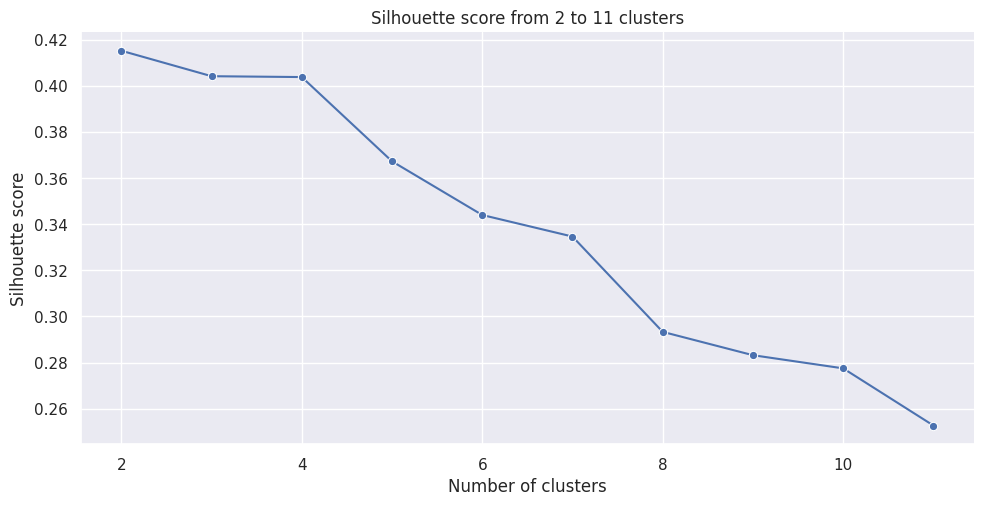

In [ ]:
sns.relplot(
  x=range(2, max_clusters),
  y=silhouette_scores,
  kind="line",
  marker="o",
  aspect=2
).set(title=f"Silhouette score from 2 to {max_clusters - 1} clusters"
).set_axis_labels("Number of clusters", "Silhouette score")
plt.show()

### 1.2. Explore the cluster means

#### 1.2.1. KMeans (Column averages)

In [ ]:
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans.fit(minmax_df)
cluster_labels = kmeans.labels_
minmax_df["cluster"] = cluster_labels

In [ ]:
minmax_df.groupby(by="cluster").mean()

,danceability,energy,acousticness,instrumentalness,valence,tempo
cluster,,,,,,
0,0.617333,0.365741,0.738008,0.744567,0.556648,0.554930
1,0.731054,0.744145,0.103992,0.018787,0.713888,0.558060
2,0.481887,0.258554,0.813818,0.033402,0.322452,0.524346
3,0.308366,0.896842,0.012635,0.802939,0.260809,0.572463
4,0.458536,0.826338,0.049857,0.055626,0.275402,0.581395
5,0.656303,0.583127,0.554100,0.016052,0.723430,0.559199
6,0.306996,0.115611,0.946605,0.883966,0.134312,0.483073


#### 1.2.2. Radar chart

In [ ]:
cluster_traces = []
feature_names = minmax_df.columns
cluster_feature_means = minmax_df.groupby("cluster").mean()
for cluster_id in sorted(minmax_df["cluster"].unique()):
  mean_feature_values = cluster_feature_means.loc[cluster_id]
  trace = go.Scatterpolar(r=mean_feature_values, theta=feature_names, fill="toself", name=f"Cluster {cluster_id}")
  cluster_traces.append(trace)

In [ ]:
fig = go.Figure()
fig.add_traces(cluster_traces)
fig.update_layout(
  title_text="Radar chart of mean feature values by cluster",
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 1]
    )
  ),
  showlegend=True
)
fig.show()

## 2. MinMaxScaler and DBSCAN

In [ ]:
minmax_dbscan_df = minmax_df.drop(columns="cluster")

### 2.1. Choosing Epsilon

In [ ]:
k = 3
nn = NearestNeighbors(n_neighbors=k)
nn.fit(minmax_dbscan_df)
distances, _ = nn.kneighbors(minmax_dbscan_df)
k_distances = [row[k-1] for row in distances]
sorted_k_distances = sorted(k_distances)

### 2.2. Plot the k-Distance Graph

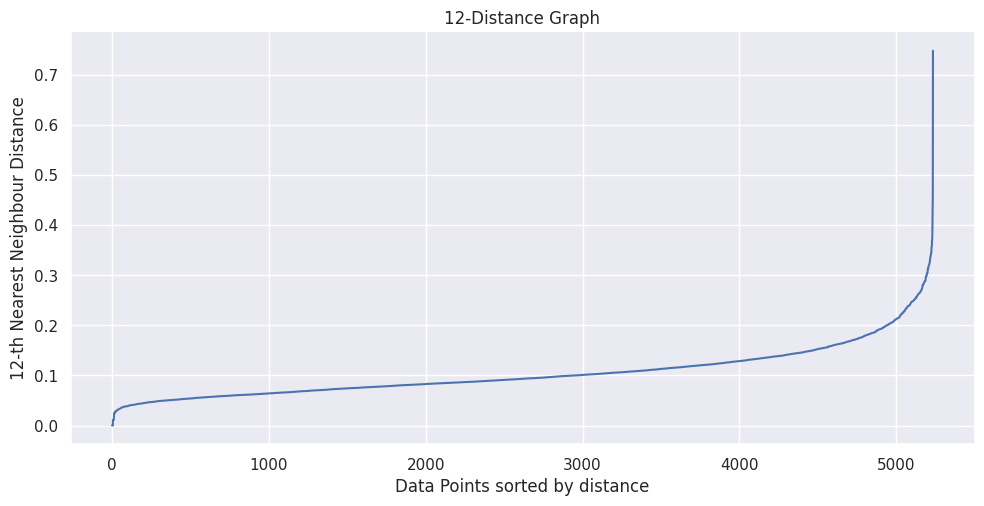

In [ ]:
sns.relplot(
  kind="line",
  data={"index": range(len(sorted_k_distances)), "distance": sorted_k_distances},
  x="index",
  y="distance",
  aspect=2
).set_axis_labels("Data Points sorted by distance", f"{k}-th Nearest Neighbour Distance"
).set(title=f"{k}-Distance Graph")
plt.show()

## 3. Agglomerative Clustering

In [ ]:
agglomerative_clustering_df = minmax_scaler.fit_transform(features_df)

### 3.1. Choosing the number of clusters

In [ ]:
agglomerative_clustering_df_1 = agglomerative_clustering_df.reset_index(drop=True).copy()

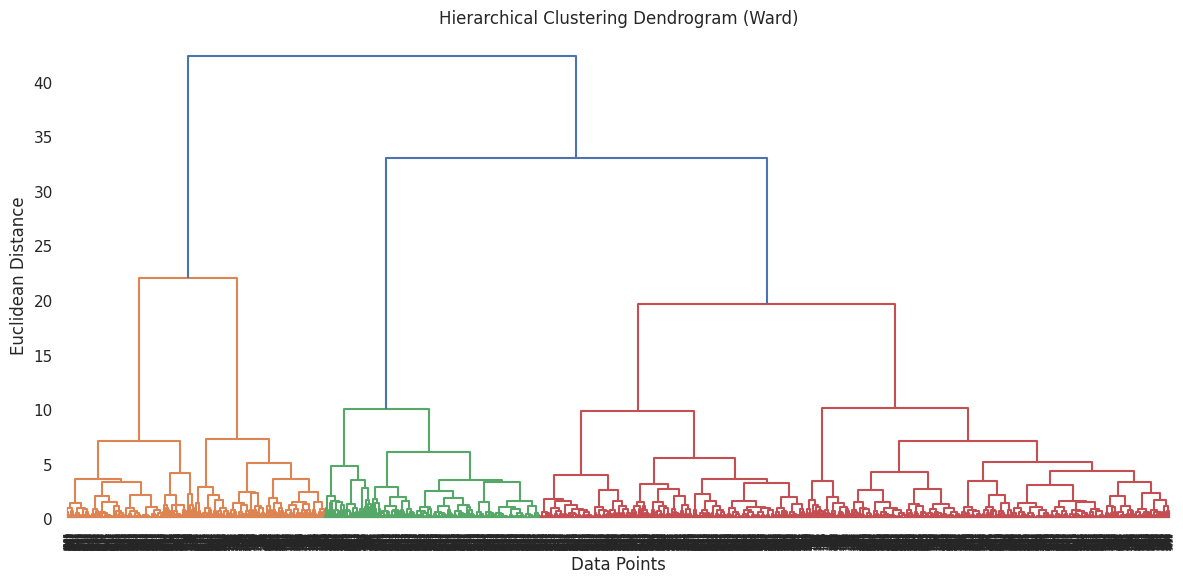

In [ ]:
linked = linkage(agglomerative_clustering_df_1, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(
  linked,
  labels=agglomerative_clustering_df_1.index.tolist(),
  orientation='top',
  distance_sort='ascending',
  show_leaf_counts=False
)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Data Points')
plt.xticks(rotation=90)
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

### 3.2. Applying Agglomerative Clustering

In [ ]:
agglomerative_clustering_df = agglomerative_clustering_df.reset_index()
agglomerative_clustering_df.sample(5)

,index,danceability,energy,acousticness,instrumentalness,valence,tempo
1588,Glamorous - Fergie,0.837642,0.755,0.289157,0.000000,0.632487,0.612131
1474,(I Can't Help) Falling In Love With You - UB40,0.663909,0.722,0.044578,0.003939,0.848731,0.805673
5196,Amériques - Edgard Varèse,0.235781,0.268,0.369478,0.452792,0.057665,0.623356
463,Oblivious - Galaxie 500,0.589452,0.707,0.032831,0.365482,0.412183,0.558891
2047,L'histoire - Subsona,0.143744,0.233,0.919679,0.951269,0.072386,0.751526


In [ ]:
n_clusters = 20
X = agglomerative_clustering_df.drop(columns=["index"], errors="ignore")
agglo_labels = AgglomerativeClustering(
  n_clusters=n_clusters,
  metric="euclidean",
  linkage="ward"
).fit_predict(X)
df_clustered = agglomerative_clustering_df.copy()
df_clustered["cluster"] = agglo_labels
df_clustered.sample(5)

,index,danceability,energy,acousticness,instrumentalness,valence,tempo,cluster
514,Green Apple - Amanaz,0.662875,0.512,0.084337,0.927919,0.638579,0.591476,9
1990,Take Me to Church - Andy Stringer,0.439504,0.144,0.988956,0.928934,0.195939,0.576560,18
4718,An Tagen wie diesen - Fettes Brot,0.686660,0.921,0.025201,0.000000,0.777665,0.740133,17
1015,The Tracks Of My Tears - Smokey Robinson & The...,0.519131,0.333,0.701807,0.000000,0.740102,0.453208,0
4280,Grotesque Laceration of Mortified Flesh - Gene...,0.217166,0.979,0.000003,0.914721,0.121827,0.377859,3


### 3.3. Visualise Clusters using t-SNE

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=3)
X = df_clustered.drop(columns=['cluster', 'index'], errors='ignore')
tsne_result = tsne.fit_transform(X)
tsne_df = pd.DataFrame(tsne_result, columns=['tsne0', 'tsne1'])
tsne_df['cluster'] = df_clustered['cluster'].values

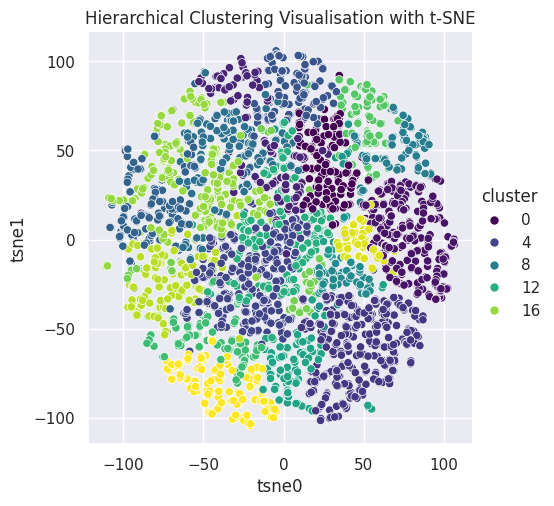

In [ ]:
sns.relplot(
  data=tsne_df,
  x='tsne0',
  y='tsne1',
  hue='cluster',
  palette='viridis'
).set(title="Hierarchical Clustering Visualisation with t-SNE")
plt.show()